In [2]:
import os
os.environ['KAGGLE_USERNAME'] = "Mwendeeee"
os.environ['KAGGLE_KEY'] = "KGAT_****************"

In [3]:
!pip uninstall -y kaggle
!pip install -U kaggle

Found existing installation: kaggle 2.0.2
Uninstalling kaggle-2.0.2:
  Successfully uninstalled kaggle-2.0.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.1 MB/s eta 0:00:00


In [4]:
!kaggle datasets list -s creditcardfraud

ref                                   title                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------  -----------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
isaikumar/creditcardfraud             Credit Card Fraud Detection Dataset    69076754  2018-05-05 09:38:01.897000           7915         87  0.47058824       
soltechhub/creditcardfraud            CreditCardFraud                           17140  2023-10-03 15:06:03.990000            126          3  0.23529412       
jeffersonvalandro/creditcardfraud     creditcardfraud                        69155672  2023-12-24 00:56:28.763000             55          0  0.29411766       
sumitchavda/creditcardfraud           creditcardfraud                         1831927  2025-01-13 09:44:45.740000             33          1  0.11764706       
melihtakyaci/creditcardfraud          CreditCa

In [5]:
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip
!ls -lh creditcard.csv

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 251MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
-rw-r--r-- 1 root root 144M Sep 20  2019 creditcard.csv


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('creditcard.csv')

print("Shape:", df.shape)
print("\n--- Info ---")
df.info()
print("\n--- Fraud rate ---")
print(df['Class'].value_counts())
print("\nFraud %:", df['Class'].mean() * 100)
print("\n--- First 5 rows ---")
df.head()

Shape: (284807, 31)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


--- Amount stats ---
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


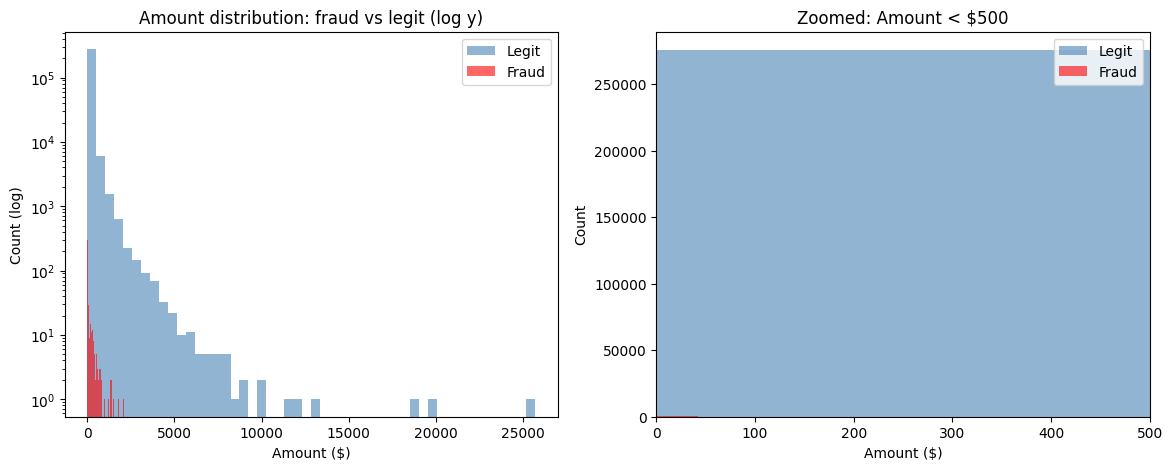

In [7]:
import matplotlib.pyplot as plt

# 1. Amount stats by class
print("--- Amount stats ---")
print(df.groupby('Class')['Amount'].describe())

# 2. One chart: Amount distribution, fraud vs legit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full range, log scale (because Amount is heavily skewed)
axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Legit', color='steelblue')
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, label='Fraud', color='red')
axes[0].set_yscale('log')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count (log)')
axes[0].set_title('Amount distribution: fraud vs legit (log y)')
axes[0].legend()

# Right: zoom into small amounts (where most fraud lives)
axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Legit', color='steelblue')
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, label='Fraud', color='red')
axes[1].set_xlim(0, 500)
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Zoomed: Amount < $500')
axes[1].legend()

In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Split 1: train (70%) vs temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Split 2: temp → val (15%) + test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Confirm the splits kept the fraud rate
print(f"Train: {X_train.shape[0]:>6} rows | fraud: {y_train.sum():>3} ({y_train.mean()*100:.3f}%)")
print(f"Val:   {X_val.shape[0]:>6} rows | fraud: {y_val.sum():>3} ({y_val.mean()*100:.3f}%)")
print(f"Test:  {X_test.shape[0]:>6} rows | fraud: {y_test.sum():>3} ({y_test.mean()*100:.3f}%)")

Train: 199364 rows | fraud: 344 (0.173%)
Val:    42721 rows | fraud:  74 (0.173%)
Test:   42722 rows | fraud:  74 (0.173%)


In [9]:
import os

# Make a folder to hold the splits
os.makedirs('splits', exist_ok=True)

# Save all three splits
X_train.to_csv('splits/X_train.csv', index=False)
X_val.to_csv('splits/X_val.csv', index=False)
X_test.to_csv('splits/X_test.csv', index=False)

y_train.to_csv('splits/y_train.csv', index=False)
y_val.to_csv('splits/y_val.csv', index=False)
y_test.to_csv('splits/y_test.csv', index=False)

print("Splits saved.")

# Confirm they're on disk
print(os.listdir('splits'))

Splits saved.
['y_train.csv', 'X_test.csv', 'y_test.csv', 'y_val.csv', 'X_train.csv', 'X_val.csv']


In [10]:
from sklearn.preprocessing import StandardScaler

# Reload splits (fresh session safe)
X_train = pd.read_csv('splits/X_train.csv')
y_train = pd.read_csv('splits/y_train.csv').squeeze()
X_val   = pd.read_csv('splits/X_val.csv')
y_val   = pd.read_csv('splits/y_val.csv').squeeze()

# Fit scaler on TRAIN ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)      # <-- transform, not fit_transform

print("Train:", X_train_scaled.shape)
print("Val:  ", X_val_scaled.shape)

Train: (199364, 30)
Val:   (42721, 30)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Fit
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict probabilities on validation
y_val_proba = model.predict_proba(X_val_scaled)[:, 1]   # P(fraud)

# Predict hard labels at default 0.5
y_val_pred = (y_val_proba >= 0.5).astype(int)

# Score
auc = roc_auc_score(y_val, y_val_proba)
print(f"AUC: {auc:.4f}")
print("\n--- Confusion matrix ---")
print(confusion_matrix(y_val, y_val_pred))
print("\n--- Classification report ---")
print(classification_report(y_val, y_val_pred, digits=4))

AUC: 0.9571

--- Confusion matrix ---
[[42635    12]
 [   30    44]]

--- Classification report ---
              precision    recall  f1-score   support

           0     0.9993    0.9997    0.9995     42647
           1     0.7857    0.5946    0.6769        74

    accuracy                         0.9990     42721
   macro avg     0.8925    0.7972    0.8382     42721
weighted avg     0.9989    0.9990    0.9989     42721



In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Ratio for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Fit — note RAW X_train, no scaling
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
xgb.fit(X_train, y_train)

# Predict on validation (RAW X_val)
y_val_proba_xgb = xgb.predict_proba(X_val)[:, 1]
y_val_pred_xgb  = (y_val_proba_xgb >= 0.5).astype(int)

# Score
auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
print(f"\nXGBoost AUC: {auc_xgb:.4f}")
print("\n--- Confusion matrix ---")
print(confusion_matrix(y_val, y_val_pred_xgb))
print("\n--- Classification report ---")
print(classification_report(y_val, y_val_pred_xgb, digits=4))

scale_pos_weight: 578.55

XGBoost AUC: 0.9765

--- Confusion matrix ---
[[42602    45]
 [   14    60]]

--- Classification report ---
              precision    recall  f1-score   support

           0     0.9997    0.9989    0.9993     42647
           1     0.5714    0.8108    0.6704        74

    accuracy                         0.9986     42721
   macro avg     0.7856    0.9049    0.8348     42721
weighted avg     0.9989    0.9986    0.9987     42721



In [13]:
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.0, 1.01, 0.01)

recalls, precisions, fps, fns = [], [], [], []

for t in thresholds:
    y_pred = (y_val_proba_xgb >= t).astype(int)
    tp = ((y_pred == 1) & (y_val == 1)).sum()
    fp = ((y_pred == 1) & (y_val == 0)).sum()
    fn = ((y_pred == 0) & (y_val == 1)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    recalls.append(rec)
    precisions.append(prec)
    fps.append(fp)
    fns.append(fn)

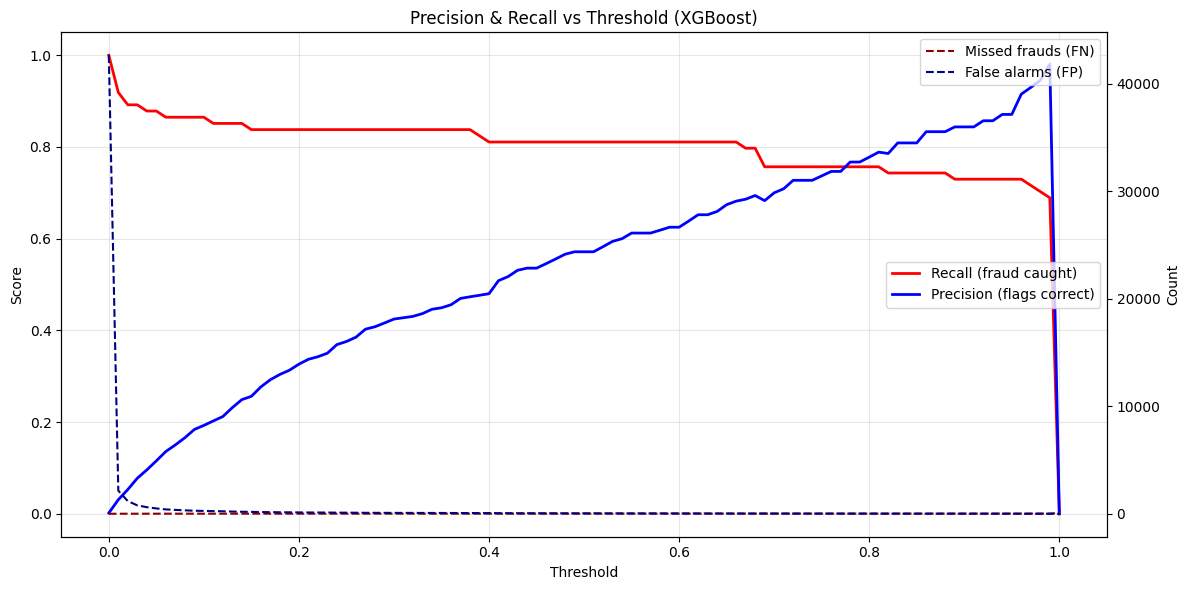

In [14]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(thresholds, recalls,     label='Recall (fraud caught)',  color='red',    linewidth=2)
ax1.plot(thresholds, precisions,  label='Precision (flags correct)', color='blue', linewidth=2)
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision & Recall vs Threshold (XGBoost)')
ax1.legend(loc='center right')
ax1.grid(alpha=0.3)

# Second y-axis for the error counts
ax2 = ax1.twinx()
ax2.plot(thresholds, fns, label='Missed frauds (FN)', color='darkred',  linestyle='--')
ax2.plot(thresholds, fps, label='False alarms (FP)',  color='navy',     linestyle='--')
ax2.set_ylabel('Count')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [15]:
f1s = [2*p*r/(p+r) if (p+r) > 0 else 0 for p, r in zip(precisions, recalls)]
best = int(np.argmax(f1s))
print(f"Max F1 threshold: {thresholds[best]:.2f}  (F1={f1s[best]:.3f}, "
      f"recall={recalls[best]:.3f}, precision={precisions[best]:.3f}, "
      f"FP={fps[best]}, FN={fns[best]})")

Max F1 threshold: 0.96  (F1=0.812, recall=0.730, precision=0.915, FP=5, FN=20)


In [18]:
idx = max(i for i, r in enumerate(recalls) if r >= 0.90)
print(f"≥90% recall at threshold: {thresholds[idx]:.2f}  "
      f"(recall={recalls[idx]:.3f}, precision={precisions[idx]:.3f}, "
      f"FP={fps[idx]}, FN={fns[idx]})")

≥90% recall at threshold: 0.01  (recall=0.919, precision=0.031, FP=2148, FN=6)


## Chosen threshold: 0.75

I compared three operating points:
- t=0.01 (≥90% recall): FP=2148, FN=6 — unusable, too many alerts
- t=0.75 (≤20 FP): FP=20, FN=18 — chosen
- t=0.96 (max F1): FP=5, FN=20 — too precision-heavy for fraud

I chose 0.75 because I weighted missed fraud more than investigation cost.

In [19]:
idx = min(i for i, fp in enumerate(fps) if fp <= 20)
print(f"≤20 false alarms at threshold: {thresholds[idx]:.2f}  "
      f"(recall={recalls[idx]:.3f}, precision={precisions[idx]:.3f}, "
      f"FP={fps[idx]}, FN={fns[idx]})")

≤20 false alarms at threshold: 0.75  (recall=0.757, precision=0.737, FP=20, FN=18)


In [20]:
import pandas as pd

X_test = pd.read_csv('splits/X_test.csv')
y_test = pd.read_csv('splits/y_test.csv').squeeze()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Fraud count in test:", y_test.sum(), "/", len(y_test))
print("Fraud rate:", y_test.mean())
print("Columns match train:", X_test.columns.equals(X_train.columns))

X_test shape: (42722, 30)
y_test shape: (42722,)
Fraud count in test: 74 / 42722
Fraud rate: 0.0017321286456626562
Columns match train: True


In [21]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

y_test_proba = xgb.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= 0.75).astype(int)

print(f"Test AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
print("\nConfusion matrix (TN, FP / FN, TP):")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test AUC: 0.9571

Confusion matrix (TN, FP / FN, TP):
[[42635    13]
 [   15    59]]

Classification report:
              precision    recall  f1-score   support

           0     0.9996    0.9997    0.9997     42648
           1     0.8194    0.7973    0.8082        74

    accuracy                         0.9993     42722
   macro avg     0.9095    0.8985    0.9039     42722
weighted avg     0.9993    0.9993    0.9993     42722



In [22]:
!ls -la /content/

total 214852
drwxr-xr-x 1 root root      4096 Oct  2 13:55 .
drwxr-xr-x 1 root root      4096 Oct  2 13:45 ..
drwxr-xr-x 4 root root      4096 Sep 16 13:26 .config
-rw-r--r-- 1 root root 150828752 Sep 20  2019 creditcard.csv
-rw-r--r-- 1 root root  69155672 Sep 20  2019 creditcardfraud.zip
drwxr-xr-x 1 root root      4096 Sep 16 13:26 sample_data
drwxr-xr-x 2 root root      4096 Oct  2 13:56 splits


In [23]:
import os
print(os.getcwd())
print(os.listdir('.'))

/content
['.config', 'creditcardfraud.zip', 'creditcard.csv', 'splits', 'sample_data']


In [24]:
!mkdir -p /content/fraud-detection
!cp -r /content/splits /content/fraud-detection/
!ls -la /content/fraud-detection/

total 12
drwxr-xr-x 3 root root 4096 Oct  2 14:47 .
drwxr-xr-x 1 root root 4096 Oct  2 14:47 ..
drwxr-xr-x 2 root root 4096 Oct  2 14:47 splits


In [25]:
%%writefile /content/fraud-detection/.gitignore
# Data — do not commit (Kaggle terms + size)
creditcard.csv
creditcardfraud.zip
*.zip

# Splits are regenerable from the notebook
splits/

# Colab / Python cruft
sample_data/
.config/
.ipynb_checkpoints/
__pycache__/
*.pyc

# Secrets — NEVER commit
kaggle.json
.env

Writing /content/fraud-detection/.gitignore


In [26]:
!cd /content/fraud-detection && git init && git branch -M main
!cd /content/fraud-detection && git add . && git status

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/fraud-detection/.git/
On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .gitignore



In [27]:
!git config --global init.defaultBranch main

In [30]:
!git config --global user.email "mwendekiindu@gmail.com"
!git config --global usern.name "Mwende-Fifi"

In [31]:
!cd /content/fraud-detection && git commit -m "Add .gitignore (exclude raw data, splits, secrets)"

[main (root-commit) 04a3ab7] Add .gitignore (exclude raw data, splits, secrets)
 1 file changed, 18 insertions(+)
 create mode 100644 .gitignore


In [32]:
!cd /content/fraud-detection && git log --oneline

04a3ab7 (HEAD -> main) Add .gitignore (exclude raw data, splits, secrets)


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [34]:
!find /content/drive/MyDrive -name "01_fraud.ipynb" 2>/dev/null

/content/drive/MyDrive/Colab Notebooks/01_fraud.ipynb


In [36]:
!cp /content/drive/MyDrive/Colab Notebooks/01_fraud.ipynb /content/fraud-detection/

cp: cannot stat '/content/drive/MyDrive/Colab': No such file or directory
cp: cannot stat 'Notebooks/01_fraud.ipynb': No such file or directory
